In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))  # Adjust path to root directory ml_project

from src.utils.utils import load_file
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
restaurant_most_frequent_ings_file = '../../data/kaggle/Restaurant_frequent_ings.csv' 
df_restaurant_freq_ings = load_file(restaurant_most_frequent_ings_file)

In [3]:
# Convert Date_time to datetime
df_restaurant_freq_ings.loc[:, 'DateTime'] = pd.to_datetime(df_restaurant_freq_ings['DateTime'])
display(df_restaurant_freq_ings)

# Filter rows by SUGAR
df_sugar_usage = df_restaurant_freq_ings[df_restaurant_freq_ings['Ingredient'] == 'sugar'].copy()

# Sort by Date_time
df_sugar_usage_sort = df_sugar_usage.sort_values(by='DateTime')

,OrderID,DateTime,Shift,DayType,DayOfWeek,PartySize,Category,MenuItem,ItemPrice,ItemQty,Factor,Ingredient,Quantity per Unit,Total Quantity
0,1,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,gobi manchurian,14.0,1,1.082508,ginger root,1.510,1.634587
1,1,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,gobi manchurian,14.0,1,1.082508,all purpose flour,10.447,11.308964
2,1,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,gobi manchurian,14.0,1,1.082508,milk,5.127,5.550020
3,2,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,flatbread,11.0,1,1.082508,dry yeast,8.260,8.941518
4,2,2019-01-01 11:30:00,Lunch,Weekday,Tuesday,4,Starter,flatbread,11.0,1,1.082508,sugar,4.190,4.535710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83074,18100,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Breads,garlic naan,3.5,2,1.465347,bread flour,60.330,88.404356
83075,18100,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Breads,garlic naan,3.5,2,1.465347,sugar,8.378,12.276673
83076,18100,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Breads,garlic naan,3.5,2,1.465347,salt,0.910,1.333465
83077,18100,2019-06-30 20:30:00,Dinner,Weekend,Sunday,1,Breads,garlic naan,3.5,2,1.465347,egg,6.333,9.280040


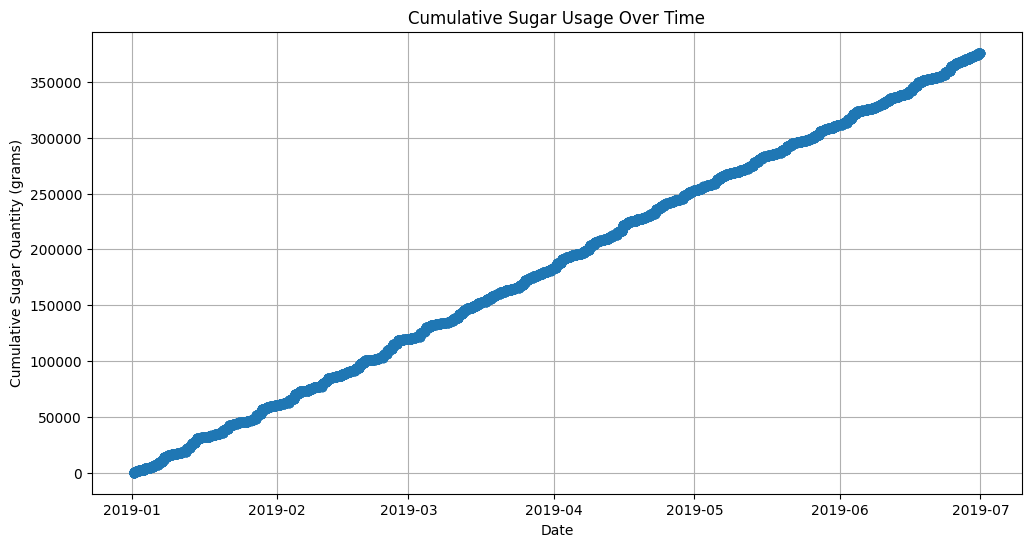

In [5]:
# Compute cumulative sum of Quantity
df_sugar_usage_sort.loc[:, 'CumulativeQuantity'] = df_sugar_usage['Total Quantity'].cumsum()

# Plot cumulative sugar quantity over time
plt.figure(figsize=(12, 6))
plt.plot(df_sugar_usage_sort['DateTime'], df_sugar_usage_sort['CumulativeQuantity'], marker='o')
plt.title('Cumulative Sugar Usage Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Sugar Quantity (grams)')
plt.grid(True)
plt.show()

,DateTime,Total Quantity
0,2019-01-01 11:30:00,19.270812
1,2019-01-01 11:40:00,1.131221
2,2019-01-01 11:50:00,99.090640
3,2019-01-01 12:05:00,49.451142
4,2019-01-01 12:10:00,288.765571
...,...,...
1805,2019-06-30 12:20:00,119.712950
1806,2019-06-30 12:30:00,393.281426
1807,2019-06-30 18:30:00,21.477584
1808,2019-06-30 19:00:00,201.883723


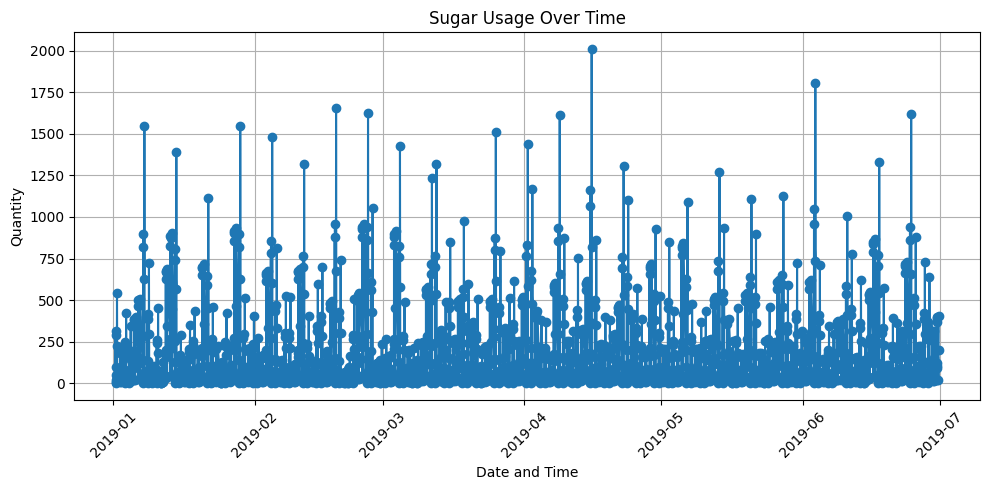

In [6]:
df_groupby_datetime = df_sugar_usage.groupby('DateTime')['Total Quantity'].sum().reset_index()
display(df_groupby_datetime)

plt.figure(figsize=(10, 5))
plt.plot(df_groupby_datetime['DateTime'], df_groupby_datetime['Total Quantity'], marker='o')

# Step 3: Customize the plot
plt.title('Sugar Usage Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Quantity')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Step 4: Show the plot
plt.show()

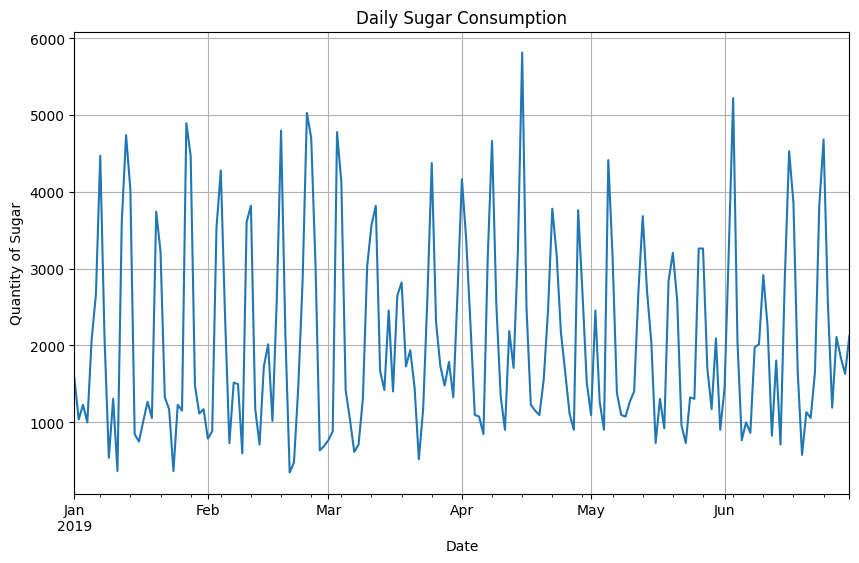

In [11]:
# Resample the data by day and sum the quantities
daily_sugar = df_sugar_usage['Total Quantity'].resample('D').sum()

# Plot the data
plt.figure(figsize=(10, 6))
daily_sugar.plot()
plt.title('Daily Sugar Consumption')
plt.xlabel('Date')
plt.ylabel('Quantity of Sugar')
plt.grid(True)
plt.show()

DateTime
2019-01-06     9576.939749
2019-01-13    17119.499512
2019-01-20    12705.278785
2019-01-27    13357.815762
2019-02-03    13434.584818
2019-02-10    14586.120660
2019-02-17    13050.739538
2019-02-24    17100.307248
2019-03-03    15507.349333
2019-03-10    12244.664449
2019-03-17    16985.153663
2019-03-24    12283.048977
2019-03-31    15699.271974
2019-04-07    15967.963670
2019-04-14    16562.923855
2019-04-21    15795.233294
2019-04-28    16562.923855
2019-05-05    14336.621228
2019-05-12    12071.934073
2019-05-19    14221.467644
2019-05-26    13377.008026
2019-06-02    13837.622363
2019-06-09    13895.199155
2019-06-16    15910.386878
2019-06-23    13741.661043
2019-06-30    16140.694046
Freq: W-SUN, Name: Total Quantity, dtype: float64

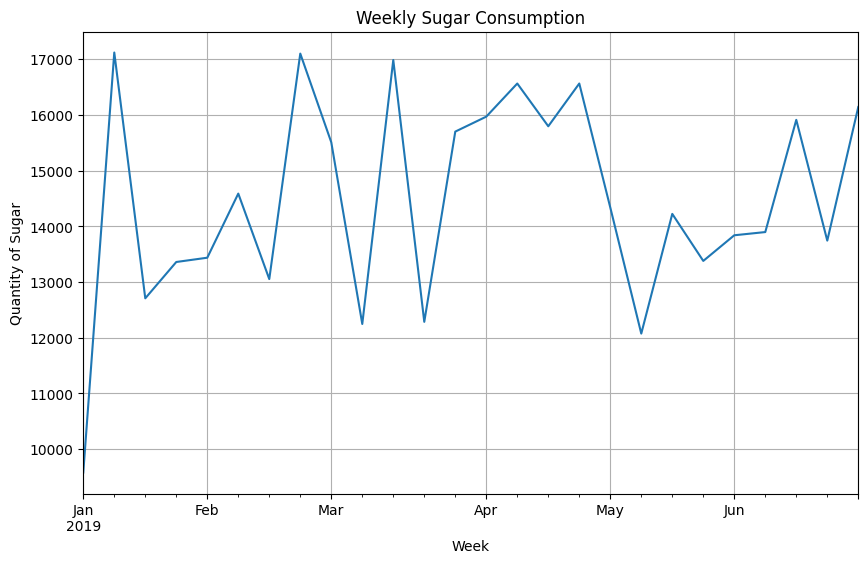

In [10]:
#df_sugar_usage['Date_time'] = pd.to_datetime(df_sugar_usage['Date_time'])
# Set the date column as the index
#df_sugar_usage.set_index('Date_time', inplace=True)

# Resample the data by week and sum the quantities
weekly_sugar = df_sugar_usage['Total Quantity'].resample('W').sum()

display(weekly_sugar)

# Plot the data
plt.figure(figsize=(10, 6))
weekly_sugar.plot()
plt.title('Weekly Sugar Consumption')
plt.xlabel('Week')
plt.ylabel('Quantity of Sugar')
plt.grid(True)
plt.show()